# Phase 1 — Variance du LSTM sur plusieurs graines

Objectif : le LSTM de `05_lstm_fd001.ipynb` bat nettement la baseline (RMSE 13.1 vs 17.9), mais
avec une seule graine on ne peut pas savoir si c'est un vrai gain ou juste une bonne (ou
mauvaise) initialisation. On ré-entraîne donc le même modèle, sur le même split train/val,
avec 5 graines différentes, et on regarde la dispersion des scores.

**Point important** : seule la graine du MODÈLE change (initialisation des poids, ordre des
batches). Le split train/val reste fixe (seed=42, comme dans les notebooks précédents) : on
veut isoler l'instabilité de l'entraînement, pas la mélanger avec un effet "on a eu un
découpage favorable".

Critère « fait » (plan d'exécution, Phase 1) : résultats en moyenne ± écart-type.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.metrics import asymmetric_score, rmse
from src.preprocessing import add_piecewise_rul, compute_norm_stats, make_windows, normalize, select_features, split_by_unit
from src.torch_model import RULRegressor, set_seed, train_model

SPLIT_SEED = 42  # fixe : même train/val que 04_baseline_fd001.ipynb et 05_lstm_fd001.ipynb
MODEL_SEEDS = [0, 1, 2, 3, 4]  # variables : c'est leur effet qu'on mesure ici
WINDOW_SIZE = 30
RUL_CAP = 125

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

raw = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None)
raw = raw.iloc[:, : len(COL_NAMES)]
raw.columns = COL_NAMES

train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SPLIT_SEED)
selected_sensors = select_features(train_raw, SENSOR_NAMES, std_threshold=1e-2)
norm_stats = compute_norm_stats(train_raw, selected_sensors)

train_norm = normalize(train_raw, selected_sensors, norm_stats)
val_norm = normalize(val_raw, selected_sensors, norm_stats)

train_rul = add_piecewise_rul(train_norm, cap=RUL_CAP)
val_rul = add_piecewise_rul(val_norm, cap=RUL_CAP)

X_train, y_train, _ = make_windows(train_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
X_val, y_val, _ = make_windows(val_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")

X_train.shape, X_val.shape

((14459, 30, 14), (3272, 30, 14))

In [2]:
rows = []

for seed in MODEL_SEEDS:
    set_seed(seed)  # avant la construction du modèle : l'initialisation des poids en dépend
    model = RULRegressor(n_features=len(selected_sensors), hidden_size=64)
    model, _ = train_model(model, X_train, y_train, X_val, y_val, epochs=50, lr=1e-3, batch_size=64, seed=seed)

    model.eval()
    with torch.no_grad():
        device = next(model.parameters()).device
        y_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device)).cpu().numpy()

    rows.append({
        "graine": seed,
        "RMSE": rmse(y_val, y_pred),
        "score_asymétrique": asymmetric_score(y_val, y_pred),
    })
    print(f"graine {seed} : RMSE={rows[-1]['RMSE']:.3f}, score_asymétrique={rows[-1]['score_asymétrique']:.1f}")

seed_results = pd.DataFrame(rows)
seed_results

graine 0 : RMSE=13.397, score_asymétrique=15141.7


graine 1 : RMSE=12.990, score_asymétrique=13712.0


graine 2 : RMSE=13.921, score_asymétrique=18203.8


graine 3 : RMSE=13.034, score_asymétrique=12840.5


graine 4 : RMSE=12.918, score_asymétrique=10819.8


,graine,RMSE,score_asymétrique
0,0,13.396928,15141.745925
1,1,12.989759,13711.973469
2,2,13.921278,18203.819701
3,3,13.034180,12840.486163
4,4,12.918413,10819.765593


In [3]:
summary = seed_results[["RMSE", "score_asymétrique"]].agg(["mean", "std"])
summary

,RMSE,score_asymétrique
mean,13.252112,14143.558170
std,0.417263,2757.442728


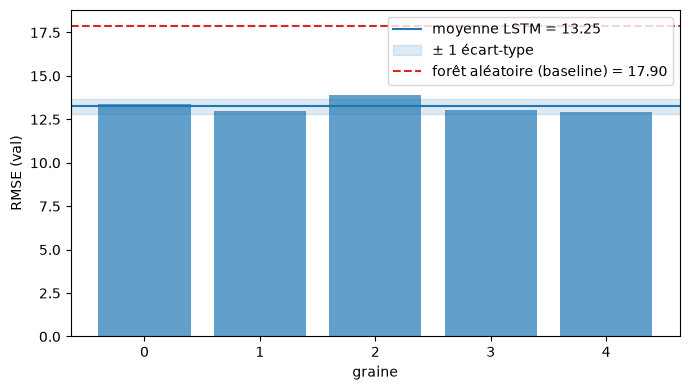

In [4]:
rmse_mean = summary.loc["mean", "RMSE"]
rmse_std = summary.loc["std", "RMSE"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(seed_results["graine"].astype(str), seed_results["RMSE"], color="tab:blue", alpha=0.7)
ax.axhline(rmse_mean, color="tab:blue", linestyle="-", linewidth=1.5, label=f"moyenne LSTM = {rmse_mean:.2f}")
ax.axhspan(rmse_mean - rmse_std, rmse_mean + rmse_std, color="tab:blue", alpha=0.15, label="± 1 écart-type")
ax.axhline(17.899715, color="tab:red", linestyle="--", linewidth=1.5, label="forêt aléatoire (baseline) = 17.90")

ax.set_xlabel("graine")
ax.set_ylabel("RMSE (val)")
ax.legend()
fig.tight_layout()

**Ce que montre cette figure** : chaque barre est le RMSE d'un entraînement complet (une
graine = une initialisation + un ordre de batches différents). La bande bleue clair est
l'intervalle ± 1 écart-type autour de la moyenne des 5 graines : c'est la marge d'incertitude
réelle de ce modèle, pas juste le résultat d'une seule graine "chanceuse". La ligne rouge
pointillée est le score de la forêt aléatoire (baseline). Si toutes les barres bleues restent
nettement en dessous de la ligne rouge, même l'écart-type ne suffit pas à remettre en cause le
gain du LSTM : la conclusion du test H1 (le deep learning apporte un gain mesurable) est
robuste au choix de la graine, pas un artefact d'une seule run favorable.